# Metrics Notebook

In [ ]:
pip install -r requirements.txt

## Import Dependencies

In [1]:
import os
import glob
import csv
import time
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.cuda.amp import GradScaler, autocast # For Mixed Precision (Speed)
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

## Model Performance Graphs

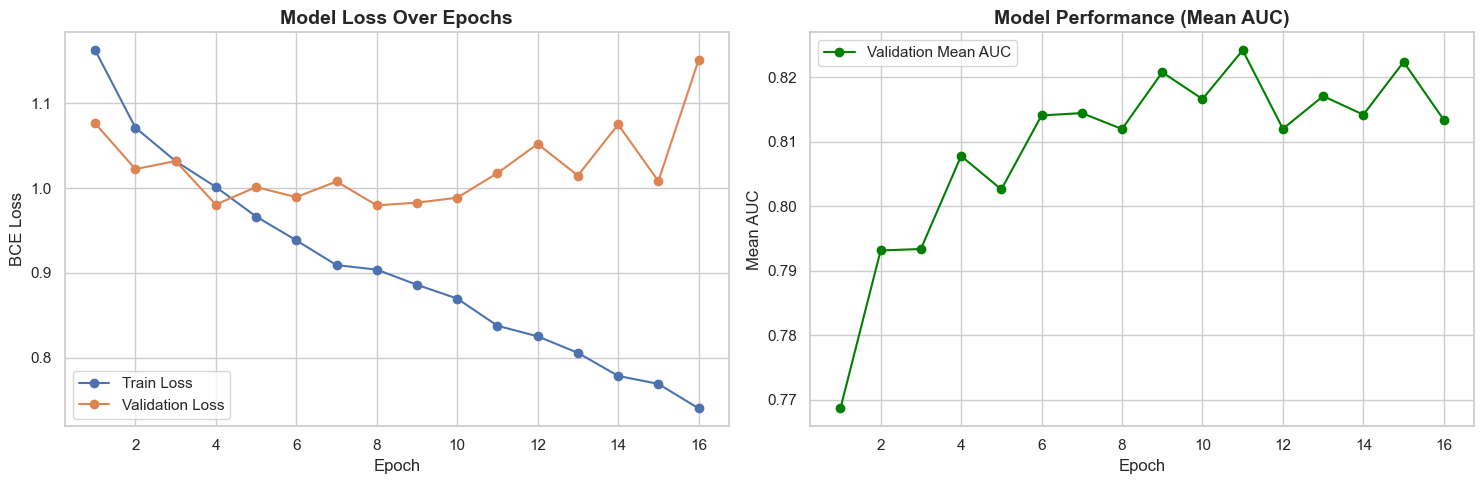

In [ ]:
# Load the data
log_df = pd.read_csv("training_log.csv")

# Set up the figure
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss Curve
ax1.plot(log_df['epoch'], log_df['train_loss'], label='Train Loss', marker='o')
ax1.plot(log_df['epoch'], log_df['val_loss'], label='Validation Loss', marker='o')
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()

# Plot 2: Mean AUC Curve
ax2.plot(log_df['epoch'], log_df['mean_auc'], label='Validation Mean AUC', color='green', marker='o')
ax2.set_title('Model Performance (Mean AUC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean AUC')
ax2.legend()

plt.tight_layout()
plt.show()

## Configuration for detailed metrics  

In [ ]:
# 1. Config & Paths 
IMAGE_ROOT = "../images"" # CHANGE TO LOCAL DATA ROOT
CSV_FILE = "../data/Data_Entry_2017.csv"
SPLIT_FILE = "../data/train_val_list.txt"
IMG_SIZE = 224
BATCH_SIZE = 16

nih_classes = sorted(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                      'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 
                      'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'])

# 2. Rebuild the Path Map
def create_path_map(root_dir):
    print("Mapping image paths...")
    image_paths = glob.glob(os.path.join(root_dir, "**", "*.png"), recursive=True)
    return {os.path.basename(p): p for p in image_paths}

path_map = create_path_map(IMAGE_ROOT)

# 3. Define Dataset and Transforms
class LetterboxPad:
    def __call__(self, image):
        w, h = image.size
        scale = min(IMG_SIZE / w, IMG_SIZE / h)
        new_w, new_h = int(w * scale), int(h * scale)
        image = image.resize((new_w, new_h), Image.Resampling.BICUBIC)
        new_img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        new_img.paste(image, ((IMG_SIZE - new_w) // 2, (IMG_SIZE - new_h) // 2))
        return new_img

class NIHDataset(Dataset):
    def __init__(self, dataframe, path_map, transform=None):
        self.df = dataframe
        self.path_map = path_map
        self.transform = transform
        
        self.df['labels_list'] = self.df['Finding Labels'].apply(
            lambda x: [] if 'No Finding' in x else x.split('|')
        )
        from sklearn.preprocessing import MultiLabelBinarizer
        self.mlb = MultiLabelBinarizer(classes=nih_classes)
        self.labels = self.mlb.fit_transform(self.df['labels_list'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Image Index']
        img_path = self.path_map.get(img_name)
        
        if img_path is None:
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.tensor(self.labels[idx], dtype=torch.float32)

        image = cv2.imread(img_path)
        if image is None:
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.tensor(self.labels[idx], dtype=torch.float32)

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        image = clahe.apply(gray)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(self.labels[idx], dtype=torch.float32)

# 4. Load Data and Recreate val_loader
print("Loading validation dataset...")
full_df = pd.read_csv(CSV_FILE)
with open(SPLIT_FILE, 'r') as f:
    train_val_list = [line.strip() for line in f.readlines()]

full_df = full_df[full_df['Image Index'].isin(train_val_list)]
full_df = full_df[full_df['Image Index'].isin(path_map.keys())]

patient_ids = full_df['Patient ID'].unique()
np.random.seed(42) 
_, val_ids = np.split(np.random.permutation(patient_ids), [int(.8*len(patient_ids))])
val_df = full_df[full_df['Patient ID'].isin(val_ids)]

val_tf = transforms.Compose([
    LetterboxPad(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_ds = NIHDataset(val_df, path_map, transform=val_tf)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ val_loader successfully created with {len(val_ds)} validation images!")

Mapping image paths...
Loading validation dataset...
✅ val_loader successfully created with 15379 validation images!


/var/folders/jn/py03l5td6rj7_ndqgf05g49r0000gn/T/ipykernel_48993/3389196809.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['labels_list'] = self.df['Finding Labels'].apply(


## Class Level Metrics (This cell may take a while to run)

In [4]:
# 1. Setup Device and Class Names
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
nih_classes = sorted(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                      'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 
                      'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'])

# 2. Build the Model and Load Best Weights
print("Initializing DenseNet-121 and loading weights...")
model = models.densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, len(nih_classes))
model.load_state_dict(torch.load("densenet_best.pth", map_location=device))
model = model.to(device)
model.eval()

# 3. Run Inference on Validation Data
all_preds = []
all_labels = []

print("Running inference on validation data... (This might take a minute)")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs)
        
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# 4. Apply Threshold and Calculate Metrics
THRESHOLD = 0.5
binary_preds = (all_preds >= THRESHOLD).astype(int)

print("\n5. Calculating Metrics on Test Set...")
print("===============================================================================")
print(f"{'Class':<25} {'AUC':>8} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-------------------------------------------------------------------------------")

auc_list, prec_list, rec_list, f1_list = [], [], [], []

for i, class_name in enumerate(nih_classes):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    prec = precision_score(all_labels[:, i], binary_preds[:, i], zero_division=0)
    rec = recall_score(all_labels[:, i], binary_preds[:, i], zero_division=0)
    f1 = f1_score(all_labels[:, i], binary_preds[:, i], zero_division=0)
    
    auc_list.append(auc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    
    print(f"{class_name:<25} {auc:8.4f} {prec:12.4f} {rec:10.4f} {f1:10.4f}")

print("-------------------------------------------------------------------------------")

# 5. Calculate Averages and Overall Accuracy
macro_auc = np.mean(auc_list)
macro_prec = np.mean(prec_list)
macro_rec = np.mean(rec_list)
macro_f1 = np.mean(f1_list)

print(f"{'MACRO AVG':<25} {macro_auc:8.4f} {macro_prec:12.4f} {macro_rec:10.4f} {macro_f1:10.4f}\n")

exact_match = accuracy_score(all_labels, binary_preds)
print(f"Overall (Exact Match) Accuracy: {exact_match:.4f}")

Initializing DenseNet-121 and loading weights...
Running inference on validation data... (This might take a minute)


libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error
libpng error: Read Error



5. Calculating Metrics on Test Set...
Class                          AUC    Precision     Recall         F1
-------------------------------------------------------------------------------
Atelectasis                 0.8088       0.2152     0.7217     0.3315
Cardiomegaly                0.8965       0.0814     0.7738     0.1474
Consolidation               0.7886       0.0831     0.6982     0.1485
Edema                       0.8938       0.0662     0.8045     0.1223
Effusion                    0.8836       0.3457     0.7851     0.4800
Emphysema                   0.8839       0.1558     0.5827     0.2458
Fibrosis                    0.7997       0.0592     0.5294     0.1066
Hernia                      0.9513       0.0842     0.8421     0.1531
Infiltration                0.7202       0.2522     0.6692     0.3663
Mass                        0.8223       0.1151     0.7447     0.1993
Nodule                      0.7367       0.1201     0.5880     0.1994
Pleural_Thickening          0.7850       

## Grad-CAM

Initializing DenseNet-121 and loading weights...
Image 5125 is 'No Finding'. Visualizing the model's highest guess.
Displaying Image Index: 5125 | Target Disease: Nodule


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


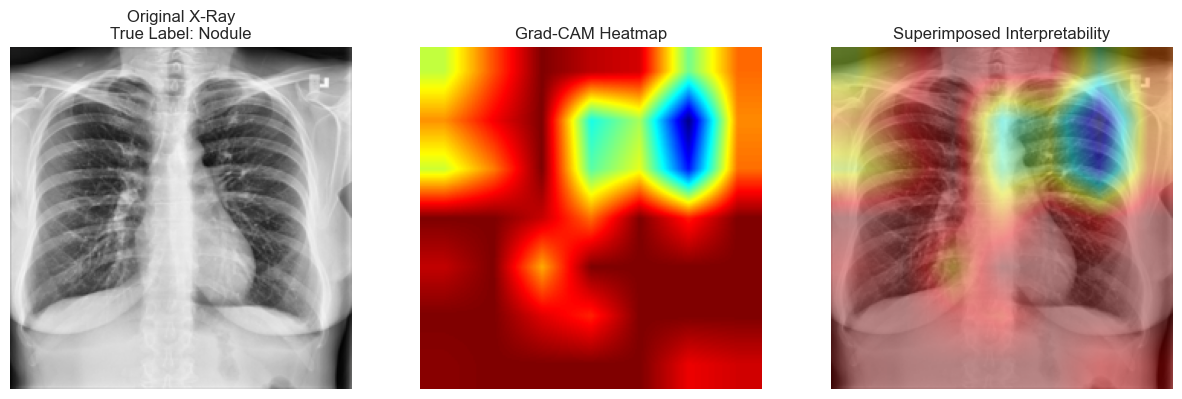

In [5]:
# 1. Setup Device and Class Names
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
nih_classes = sorted(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                      'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 
                      'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'])

# 2. Build the Model and Load Best Weights
print("Initializing DenseNet-121 and loading weights...")
model = models.densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, len(nih_classes))
model.load_state_dict(torch.load("densenet_best.pth", map_location=device))
model = model.to(device)
model.eval()

def custom_forward(x):
    features = model.features(x)
    out = F.relu(features, inplace=False) # 
    out = F.adaptive_avg_pool2d(out, (1, 1))
    out = torch.flatten(out, 1)
    out = model.classifier(out)
    return out

# Apply the patch to our loaded model
model.forward = custom_forward

class DenseNetGradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        
        # Hook into the final feature block
        target_layer = self.model.features
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, target_class_idx):
        self.model.eval()
        self.model.zero_grad()
        
        # Forward pass
        output = self.model(input_image)
        score = output[:, target_class_idx]
        
        # Backward pass
        score.backward(retain_graph=True)
        
        # Pool the gradients and weight the activations
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Clone activations so we don't modify them in place
        weighted_activations = self.activations.clone()
        for i in range(weighted_activations.shape[1]):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]
            
        # Create the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        
        # Normalize safely
        if torch.max(heatmap) > 0:
            heatmap /= torch.max(heatmap)
            
        return heatmap.cpu().detach().numpy()

# --- RUNNING GRAD-CAM ON A SAMPLE FROM VALIDATION LOADER ---
import random

# --- RUNNING GRAD-CAM ON A RANDOM VALIDATION SAMPLE ---
cam = DenseNetGradCAM(model)

# 1. Pick a random index from the validation dataset
random_idx = random.randint(0, len(val_ds) - 1)
sample_img_raw, sample_label = val_ds[random_idx]

# 2. Add the batch dimension (1, C, H, W) and send to device
sample_img = sample_img_raw.unsqueeze(0).to(device)

# 3. If "No Finding" is the only label visualize the highest activated class instead
if torch.sum(sample_label) == 0:
    print(f"Image {random_idx} is 'No Finding'. Visualizing the model's highest guess.")
    model.eval()
    with torch.no_grad():
        preds = model(sample_img)
    target_idx = torch.argmax(preds).item()
    target_disease = nih_classes[target_idx]
else:
    # Pick the highest true label to visualize
    target_idx = torch.argmax(sample_label).item() 
    target_disease = nih_classes[target_idx]

print(f"Displaying Image Index: {random_idx} | Target Disease: {target_disease}")

# Generate Heatmap
heatmap = cam.generate_heatmap(sample_img, target_idx)

# Format the heatmap for plotting
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Un-normalize the original image for display
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
# Note: we use sample_img_raw here instead of images[0]
orig_img = inv_normalize(sample_img_raw).permute(1, 2, 0).cpu().numpy()
orig_img = np.clip(orig_img, 0, 1)

# Superimpose heatmap onto original X-ray
superimposed = heatmap * 0.4 + (orig_img * 255) * 0.6
superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)

# Plotting the results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(orig_img)
ax1.set_title(f"Original X-Ray\nTrue Label: {target_disease}")
ax2.imshow(heatmap)
ax2.set_title("Grad-CAM Heatmap")
ax3.imshow(superimposed)
ax3.set_title("Superimposed Interpretability")
for ax in [ax1, ax2, ax3]: ax.axis('off')
plt.show()